This notebook contains code to load the ML6 dataset and peform feature selection using splitted traning and testing dataset.
- Train the model without normalization

In [1]:
import sys
sys.path.insert(0, '../')

In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.base import clone

# load local variables
from src.config import *
from src.load_models import select_model
from src.utils import calculate_r2_score, calculate_per_diff, calculate_combined_r2_and_per_diff, find_adj_score, combine_all_batches, split_batches_back, perform_combat_normalization
from src.utils import calculate_y_LOD
from src.feature_selection import ModelSelection
from src.graph_visualization import feature_selection_tabularize, create_correlation_matrix


In [3]:
# Load Extracted features dataset
ML6_1 = pd.read_excel('/Users/sangam/Desktop/Epilepsey/Code/vgramreg/dataset/ML6/Day 1 Data/feature_extraction_noise_None.xlsx')
ML6_2 = pd.read_excel('/Users/sangam/Desktop/Epilepsey/Code/vgramreg/dataset/ML6/Day 2 Data/feature_extraction_noise_None.xlsx')

ML6_2['label'] = ML6_2['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))
ML6_2 = ML6_2.drop(columns='file')

ML6_1['label'] = ML6_1['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))
ML6_1 = ML6_1.drop(columns='file')

In [4]:
ML6_1['dataset_name'] = '1'
ML6_2['dataset_name'] = '2'

final_dataset = pd.concat([ML6_1, ML6_2], ignore_index=True)

In [5]:
final_dataset.rename(columns={"PH": 'max(S)', 'signal_std':'std(S)', 'signal_mean':'mean(S)', 'peak area':'area(S)', \
                        'dS_dV_area':'area(dS/dV)', 'dS_dV_max_peak':'max(dS/dV)', 'dS_dV_min_peak':'min(dS/dV)',\
                    'dS_dV_peak_diff':'max(dS/dV) - min(dS/dV)', \
                    'peak V':'V_max(S)', 'dS_dV_max_V':'V_max(dS/dV)', 'dS_dV_min_V':'V_min(dS/dV)',\
        }, inplace = True)

In [6]:
final_dataset = final_dataset[['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2', 'label', 'dataset_name']]
final_dataset

,area(S),max(S),max(dS/dV),min(dS/dV),V_max(S),vcenter,V_max(dS/dV),V_min(dS/dV),f1,f2,label,dataset_name
0,1.1035,0.017510,0.3809,-0.5244,1.0509,1.0463,1.032,1.080,0.7072,-16.8102,4,1
1,2.2940,0.033824,0.6989,-0.8795,1.0582,1.0480,1.036,1.092,1.3894,34.8073,4,1
2,3.1824,0.051996,1.2167,-1.4382,1.0461,1.0538,1.016,1.072,1.5455,34.8061,8,1
3,3.1574,0.054249,1.2173,-1.6441,1.0484,1.0491,1.020,1.076,1.0457,-4.3396,8,1
4,5.5264,0.090447,2.1041,-2.5004,1.0657,1.0712,1.036,1.092,1.2007,25.1452,16,1
...,...,...,...,...,...,...,...,...,...,...,...,...
220,8.8870,0.136665,2.9070,-3.4862,1.0594,1.0619,1.028,1.088,1.4306,44.7135,16,2
221,2.0187,0.031516,0.6744,-0.8230,1.0517,1.0510,1.020,1.076,1.1217,14.4177,8,2
222,4.3946,0.065702,1.3993,-1.5154,1.0545,1.0570,1.016,1.084,0.9395,35.8728,12,2
223,1.8908,0.024186,0.5026,-0.6235,1.0352,1.0270,1.016,1.076,0.7506,-3.4662,4,2


Text(0.5, 1.0, 'Box Plot for ML6 1 and 2 datset')

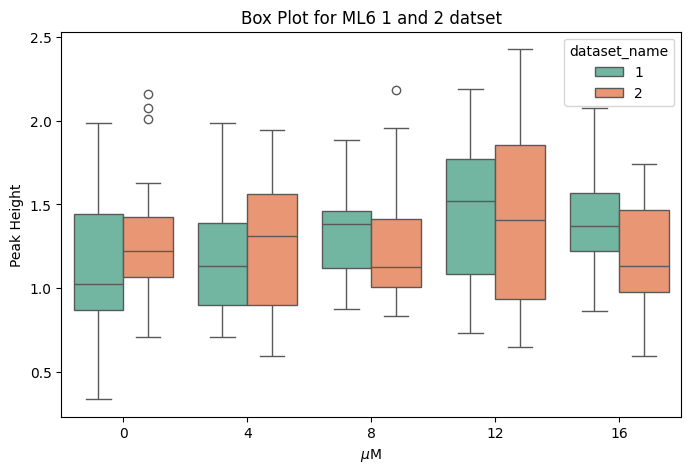

In [7]:
label_order = [0, 4, 8, 12, 16]
plt.figure(figsize=(8, 5))
sns.boxplot(x="label", y="f1", data=final_dataset, hue="dataset_name", palette="Set2", order=label_order)

# Customize the plot
plt.xlabel(r"$\mu $M")
plt.ylabel("Peak Height")
plt.title("Box Plot for ML6 1 and 2 datset")

In [8]:
Y           = final_dataset['label']
X           = final_dataset.drop(columns=['label', 'dataset_name'])

X_train, X_test, y_train, y_test  = train_test_split(X, Y, test_size=0.4, shuffle=True, random_state=42, stratify=Y)

In [9]:
# Create a Correlaion heat map
PATH_TO_SAVE = '../results/Journal_paper/'
# create_correlation_matrix(X, PATH_TO_SAVE)

In [10]:
def get_best_score_per_feature_count(feature_scores: dict, only_best=True, higher_better=True):
    best_score_feature_set = []
    feature_scores = [feature_scores[-1]] if only_best else feature_scores

    for ind, feature_set in enumerate(feature_scores):
        feature_comb = list(feature_set.keys())
        scores       = list(feature_set.values())
        best_ind     = np.argmax(scores) if higher_better else np.argmin(scores)

        best_score_feature_set.append((('Prev + ' if ind!=0 else '') + eval(feature_comb[best_ind])[-1], scores[best_ind]))
        

    return best_score_feature_set[-1] if only_best else best_score_feature_set

In [11]:
def plot_model_vs_score(score_df:dict, 
                       metric='',
                       save_path='') -> None:     
    

    ax = score_df.plot(x='Models', y="Scores", kind='bar', legend=False)
    plt.legend()
    for i, p in enumerate(ax.patches):
        ax.annotate(str(round(p.get_height(), 4)), (p.get_x() + p.get_width() / 2., 0.3 * p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',  rotation='vertical', fontsize=10, )
    
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Feature set')
    plt.ylabel(metric)
    plt.legend().set_visible(False)
    if save_path!='':
        plt.savefig(f'{save_path}', dpi=300, bbox_inches='tight')
    

In [13]:
# List of models
models = ['KNN', 'Linear']
root_path = '../results/Journal_paper'

# Calcualte y_LOD
y_LOD     = calculate_y_LOD(X_train, y_train)
kf        = KFold(n_splits=5, shuffle=True, random_state=42)
add_alpha = False

find_class_stratified_score = True

r2_score_val,  per_diff_val  = {'Models':[], 'Scores':[]}, {'Models':[], 'Scores':[]}
r2_score_test, per_diff_test = {'Models':[], 'Scores':[]}, {'Models':[], 'Scores':[]}

r2_score_class_stratified_test = {'Models':[], '0':[], '5':[], '8':[], '10':[], '15':[], '16':[]} if add_alpha else {'Models':[], '0':[], '8':[], '16':[]}
per_diff_class_stratified_test = {'Models':[], '0':[], '5':[], '8':[], '10':[], '15':[], '16':[]} if add_alpha else {'Models':[], '0':[], '8':[], '16':[]}

metric  = 'r2'
higher_better=False if metric=='per_diff' else True

cross_feature_score = {'Models':[], 'Feature_Selected_ON':[], 'Feature_set':[], 'Other_Metric_Score':[]}

for model_name in models:
   
    model             = ModelSelection(model_name, X_train, y_train)
    selected_features, best_params = model.find_best_features(kf, metric=metric, use_adjusted_r2=True)
    print(best_params)
    df                = feature_selection_tabularize(selected_features)

    df.to_excel(f'../results/Journal_paper/Feature_selection/{model_name}_feature_selection_{metric}.xlsx')
    best_score_feature_set = get_best_score_per_feature_count(selected_features, only_best=False, higher_better=higher_better)
    break

    save_path = f'../results/Journal_paper/Comparison_barchart/{model_name}_{metric}.png'
    best_score_df = pd.DataFrame(best_score_feature_set, columns=["Models", "Scores"])
    plot_model_vs_score(best_score_df, metric, save_path)

    # Train the model and calculate different metric scores.
    selected_feature_set = [(i[0].split('+')[-1]).strip() for i in best_score_feature_set]

    cross_feature_score['Models'].append(model_name)
    cross_feature_score['Feature_Selected_ON'].append(f'{metric} : {round(best_score_feature_set[-1][-1], 4)}')
    cross_feature_score['Feature_set'].append(selected_feature_set)

    temp_holder = []
    for test_metric in ['r2', 'combine', 'per_diff']:
        if (metric != test_metric):
           
            score = model.find_score_KFold(kf, selected_feature_set, test_metric, use_adjusted_r2=True)
            temp_holder.append(f'{test_metric}: {round(score, 4)}')

    cross_feature_score['Other_Metric_Score'].append(' | '.join(temp_holder))

    
cross_feature_set_df = pd.DataFrame(cross_feature_score)
cross_feature_set_df.to_excel(os.path.join(root_path, f'Cross_Feature_Set/feature_selected_on_{metric}.xlsx'))

[{'n_neighbors': 8, 'weights': 'uniform', 'metric': 'euclidean'}, {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'manhattan'}, {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'manhattan'}, {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'manhattan'}]


In [14]:
df

,Univariate Features,Scores_1,Bivariate Features,Scores_2,Trivariate Features,Scores_3,Quad,Scores_4
0,['area(S)'],0.7746,"['min(dS/dV)', 'area(S)']",0.8789,"['min(dS/dV)', 'area(S)', 'max(S)']",0.8779,"['min(dS/dV)', 'area(S)', 'V_max(S)', 'max(S)']",0.8838
1,['max(S)'],0.8243,"['min(dS/dV)', 'max(S)']",0.8730,"['min(dS/dV)', 'area(S)', 'max(dS/dV)']",0.8723,"['min(dS/dV)', 'area(S)', 'V_max(S)', 'max(dS/...",0.8744
2,['max(dS/dV)'],0.8318,"['min(dS/dV)', 'max(dS/dV)']",0.8629,"['min(dS/dV)', 'area(S)', 'V_max(S)']",0.8847,"['min(dS/dV)', 'area(S)', 'V_max(S)', 'vcenter']",0.8850
3,['min(dS/dV)'],0.8731,"['min(dS/dV)', 'V_max(S)']",0.8720,"['min(dS/dV)', 'area(S)', 'vcenter']",0.8842,"['min(dS/dV)', 'area(S)', 'V_max(S)', 'V_max(d...",0.8804
4,['V_max(S)'],0.5483,"['min(dS/dV)', 'vcenter']",0.8720,"['min(dS/dV)', 'area(S)', 'V_max(dS/dV)']",0.8805,"['min(dS/dV)', 'area(S)', 'V_max(S)', 'V_min(d...",0.8795
5,['vcenter'],0.5032,"['min(dS/dV)', 'V_max(dS/dV)']",0.8721,"['min(dS/dV)', 'area(S)', 'V_min(dS/dV)']",0.8750,"['min(dS/dV)', 'area(S)', 'V_max(S)', 'f1']",0.8657
6,['V_max(dS/dV)'],0.5480,"['min(dS/dV)', 'V_min(dS/dV)']",0.8722,"['min(dS/dV)', 'area(S)', 'f1']",0.8658,"['min(dS/dV)', 'area(S)', 'V_max(S)', 'f2']",0.6653
7,['V_min(dS/dV)'],0.4752,"['min(dS/dV)', 'f1']",0.8707,"['min(dS/dV)', 'area(S)', 'f2']",0.6675,,0.0000
8,['f1'],-0.0261,"['min(dS/dV)', 'f2']",0.3166,,0.0000,,0.0000
9,['f2'],-0.0410,,0.0000,,0.0000,,0.0000


In [15]:
best_params

[{'n_neighbors': 8, 'weights': 'uniform', 'metric': 'euclidean'},
 {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'manhattan'},
 {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'manhattan'},
 {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'manhattan'}]

In [ ]:
selected_feature_set

# Prediction models on testing resutls



In [ ]:
features_list= {'KNN':    ['min(dS/dV)', 'max(dS/dV)', 'V_max(S)', 'vcenter'], 
                'Linear': ['min(dS/dV)', 'V_max(S)','f2', 'peak curvature'], 
                'RF':     ['min(dS/dV)', 'f2', 'area(dS/dV)'], 
                'SVM':    ['max(dS/dV) - min(dS/dV)', 'min(dS/dV)', 'area(S)'], 
                'GP':     ['min(dS/dV)', 'area(S)', 'V_min(dS/dV)', 'V_max(S)']}


for metric in ['r2', 'combine', 'per_diff']:
    test_score = {'Models':[], 'Scores':[]}
    for model_name in models:
    
        selected_feature_set = features_list[model_name]
        
        # Calculate the test score on the given performance metrics
        test_score['Models'].append(model_name)
        model.fit(selected_feature_set)
        y_pred = model.model.predict(X_test[selected_feature_set])
        score  = model.find_score(y_test, y_pred, y_LOD=model.y_LOD, metric=metric, use_adjusted_r2=True, feature_len=len(selected_feature_set))
        test_score['Scores'].append(score)
    
    save_path = os.path.join(root_path, f'Test_Results/test_results_{metric}.png')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df_test_score = pd.DataFrame(test_score)
    df_test_score = df_test_score.sort_values(by='Scores')
    plot_model_vs_score(df_test_score, metric, save_path)
    plt.show()

In [ ]:
import sys
sys.path.insert(0, '../')

In [17]:
import pandas as pd
import numpy as np
from src.load_models import select_model
from typing import Tuple
from src.utils import calculate_r2_score_KFold, calculate_per_diff_KFold, calculate_combined_r2_and_per_diff_KFold

from src.load_models import select_model
from src.utils import calculate_y_LOD

from sklearn.model_selection import KFold

In [18]:
class testing:
    def __init__(self, 
                 model_name:str, 
                 X_train:pd.DataFrame, 
                 y_train:pd.Series):
        
        self.X_train, self.y_train = X_train, y_train
        self.model = select_model(model_name)
        self.model_name = model_name
        self.all_feature_scores = []
    
        self.y_LOD = calculate_y_LOD(self.X_train, self.y_train) 
        
    def list_all_parameters(self, params_dict:dict) -> pd.DataFrame:
        all_keys     = list(params_dict.keys())
        all_params   = pd.DataFrame(params_dict[all_keys[0]], columns=[all_keys[0]])

        for key in all_keys[1:]:
            all_params = all_params.merge(pd.DataFrame(params_dict[key], columns=[key]), how='cross')

        return all_params
    
    def calculate_score_hyperparameter(self, 
                                       params:dict, 
                                       metric:str, 
                                       features:list, 
                                       kf:KFold, 
                                       use_adjusted_r2:bool) -> np.float64:
        
        # Assign new parameters to the base model
        params_dict = params.to_dict()
        self.model.set_params(**params_dict)

        # Calcualte metric
        if 'r2'in metric:
            return calculate_r2_score_KFold(self.model, self.X_train[features], self.y_train, kf, use_adjusted_r2=use_adjusted_r2)

        elif metric=='per_diff':  
            return calculate_per_diff_KFold(self.model, self.X_train[features], self.y_train, self.y_LOD, kf)

        else:
            return calculate_combined_r2_and_per_diff_KFold(self.model, self.X_train[features], self.y_train, kf, self.y_LOD, use_adjusted_r2=use_adjusted_r2)


        

    def find_best_score_hyperparameter_KFold(self, 
                                  kf:KFold, 
                                  testing_feature:list, 
                                  metric:str, 
                                  use_adjusted_r2:bool) -> Tuple:
        
        all_params_df = self.list_all_parameters(param_grids[self.model_name])
        all_params_df['score'] = all_params_df.apply(self.calculate_score_hyperparameter, axis=1, args=(metric, testing_feature,kf,use_adjusted_r2))

        if metric=='per_diff': best_features = all_params_df.loc[all_params_df['score'].idxmin()]
        else: best_features = all_params_df.loc[all_params_df['score'].idxmax()]
        best_score    = best_features['score']
        return best_features.drop('score').to_dict(), best_score


In [19]:
param_grids = {'SVM':{
                    'C': [1, 10, 15, 20, 100],
                    'gamma': [0.0001, 0.0005, 0.001, 0.005, 0.01],
                    'kernel': ['rbf']},
              
              'RF': {
                    'n_estimators': [80, 100, 120],
                    'max_depth': [5, 10, 15],
                    'min_samples_split': [6, 8, 10, 16,20],
                    'min_samples_leaf': [2,4,6] 
                     },
              
              'KNN': {
                        'n_neighbors': [3, 5, 6, 7, 8, 9],
                        'weights': ['uniform', 'distance'],
                        'metric': ['euclidean', 'manhattan']
                    },
              
              'GP': {'kernel': [1.0 * RBF(length_scale=1.0), 
                                1.0 * RBF(length_scale=0.5), 
                                1.0 * RBF(length_scale=1.5), 
                                1.0 * RBF(length_scale=2.0),
                                1.0 * RBF(length_scale=2.5),
                                1.0 * Matern(length_scale=1.0, nu=1.5)],
                     'alpha': [0.001, 0.01, 0.1, 1, 1.5, 2, 2.5]},
               'Ridge': {'alpha': [0.0001, 0.0005, 0.001, 0.003, 0.005, 0.01, 0.1, 1.0]},
               'Lasso': {'alpha': [0.00001, 0.00003, 0.00005, 0.0001, 0.0003, 0.0005, 0.001]}
              }

In [22]:
model       = testing('KNN', X_train, y_train)
feature_set = ['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2']

kf        = KFold(n_splits=5, shuffle=True, random_state=42)
model.find_best_score_hyperparameter_KFold(kf, feature_set, 'per_diff', use_adjusted_r2=True)

({'n_neighbors': 3, 'weights': 'distance', 'metric': 'manhattan'},
 36.38841936643562)

In [28]:
model = select_model('KNN')
kf        = KFold(n_splits=5, shuffle=True, random_state=42)

feature_set = ['min(dS/dV)']

params = {'n_neighbors':8, 
          'weights':'uniform', 
          'metric':'euclidean'}

model.set_params(**params)
print(model.get_params())

print(calculate_r2_score_KFold(model, X_train[feature_set], y_train, kf, use_adjusted_r2=True))

print(calculate_per_diff_KFold(model, X_train[feature_set], y_train, calculate_y_LOD(X_train, y_train), kf))

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'euclidean', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 8, 'p': 2, 'weights': 'uniform'}
0.8730689571150098
23.6062272644075


In [24]:
best_params

[{'n_neighbors': 8, 'weights': 'uniform', 'metric': 'euclidean'},
 {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'manhattan'},
 {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'manhattan'},
 {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'manhattan'}]